# Two judges for the `specify` slice — reference-free vs reference-anchored

The `specify` reward is **structural ⊕ LLM trace-judge**. On this slice the structural score
**saturates at 1.0** (the model writes structurally-valid specs from the seed), so *all the
discriminating signal comes from the judge*. That makes the judge's reliability the whole game —
and motivates the question: should the judge be **reference-free** (rate the spec 0–1 in a vacuum)
or **reference-anchored** (score coverage against a per-brief `expected` behaviors checklist)?

**The worry (correct):** *without a reference you purely depend on the judge.* This notebook tests
that on the **same produced specs**, scored by **both** judges — so any difference is the anchor,
not the spec.

**Result (real data, 6 specs):** the reference-free judge emits a **near-constant ~0.91 coverage**
for every spec (it can't ground it), while the reference-anchored judge **discriminates** and catches
a spec missing 1 of 4 expected behaviors (coverage 0.75). Reference-anchored is adopted in **FR-017**.

> Analysis-only over a saved real run (`jobs/specify-judge-compare-2026-05-29.json`, gitignored).
> The dual-judging itself was done by `tasks/specify-skillopt/compare_judges.py`.

In [5]:
import sys
from pathlib import Path

# minimal path bootstrap so `utils` is importable (import setup only; helpers live in utils)
_p = Path.cwd().resolve()
_root = next((d for d in (_p, *_p.parents) if (d / "pyproject.toml").exists()), _p)
sys.path.insert(0, str(_root / "notebooks"))

from utils import repo_root
from utils.skillopt_analysis import load_json

REPO = repo_root()
CMP = REPO / "jobs" / "specify-judge-compare-2026-05-29.json"
assert CMP.exists(), f"comparison artifact missing: {CMP} (run tasks/specify-skillopt/compare_judges.py)"
data = load_json(CMP)
rows = data["rows"]
print(f"dual-judged specs: {data['n']}   (source run: {data['run']})")

dual-judged specs: 6   (source run: jobs/specify-skillopt-2026-05-29)


## Same specs, two judges — per-spec scores

`free` = reference-free (rate 0–1 in a vacuum). `ref` = reference-anchored (coverage = fraction
of the brief's `expected` behaviors the judge marks present). Watch the **coverage** columns.

In [6]:
import statistics as st

print(f"{'id':10} {'free.cov':>8} {'ref.cov':>7}  {'free.ov':>7} {'ref.ov':>7}  covered (per expected behavior)")
for r in rows:
    f, rf = r["free"], r["ref"]
    print(f"{r['id']:10} {f['coverage']:>8} {rf['coverage']:>7}  {f['overall']:>7} {rf['overall']:>7}  {rf['covered']}")

free_cov = [r["free"]["coverage"] for r in rows]
ref_cov = [r["ref"]["coverage"] for r in rows]
print(
    f"\ncoverage spread (std):  reference-free = {st.pstdev(free_cov):.4f}   "
    f"reference-anchored = {st.pstdev(ref_cov):.4f}"
)
print(
    f"coverage range:         reference-free = [{min(free_cov)}, {max(free_cov)}]   "
    f"anchored = [{min(ref_cov)}, {max(ref_cov)}]"
)
print("\n→ reference-free coverage is ~constant (it can't ground the score — a vibe).")
print("  reference-anchored coverage discriminates: it flags the spec missing an expected behavior.")

id         free.cov ref.cov  free.ov  ref.ov  covered (per expected behavior)
spec_0000       0.9     1.0     0.87  0.8833  [True, True, True, True]
spec_0009      0.92    0.75     0.88     0.8  [True, True, True, False]
spec_0001      0.91     1.0     0.83  0.8733  [True, True, True, True]
spec_0003      0.91     1.0     0.83    0.89  [True, True, True, True]
spec_0004      0.91     1.0     0.88  0.9367  [True, True, True, True]
spec_0007      0.91     1.0     0.84  0.8833  [True, True, True, True]

coverage spread (std):  reference-free = 0.0058   reference-anchored = 0.0932
coverage range:         reference-free = [0.9, 0.92]   anchored = [0.75, 1.0]

→ reference-free coverage is ~constant (it can't ground the score — a vibe).
  reference-anchored coverage discriminates: it flags the spec missing an expected behavior.


In [7]:
r9 = next(r for r in rows if r["id"] == "spec_0009")
print(f"brief: {r9['brief']}\n")
print("expected behaviors  →  covered? (reference-anchored judge):")
for beh, ok in zip(r9["expected"], r9["ref"]["covered"], strict=True):
    print(f"  [{'✓' if ok else '✗ MISSING'}] {beh}")
print(f"\nreference-free  : coverage={r9['free']['coverage']}  notes={r9['free']['notes']!r}")
print(f"reference-anchored: coverage={r9['ref']['coverage']}  notes={r9['ref']['notes']!r}")
print("\n→ the free judge gave 0.92 and a generic note; the anchored judge pinned the exact missing behavior.")

brief: A feature that lets a user schedule a message to send later and edit or cancel it before it goes out.

expected behaviors  →  covered? (reference-anchored judge):
  [✓] schedules a message to send at a future time
  [✓] lets the user edit a scheduled message before send
  [✓] lets the user cancel before send
  [✗ MISSING] sends exactly once at the scheduled time

reference-free  : coverage=0.92  notes="Success criteria lack a measurable target for edit-then-deliver correctness rate (stale-
content '0 failures' is binary and unverifiable at scale without a defined audit mechanism)"
reference-anchored: coverage=0.75  notes='Exactly-once delivery (behavior 4) is unaddressed — FR-003 guarantees delivery occurs
but the spec has no idempotency or deduplication requirement preventing double-send on job-queue retries or infrastructure resta
rts.'

→ the free judge gave 0.92 and a generic note; the anchored judge pinned the exact missing behavior.


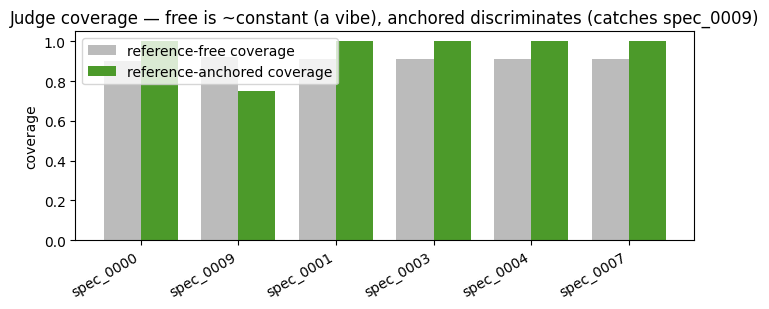

In [8]:
import matplotlib.pyplot as plt

ids = [r["id"] for r in rows]
x = range(len(ids))
w = 0.38
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar([i - w / 2 for i in x], free_cov, w, label="reference-free coverage", color="#bbb")
ax.bar(
    [i + w / 2 for i in x],
    ref_cov,
    w,
    label="reference-anchored coverage",
    color="#4c9a2a",
)
ax.set_xticks(list(x))
ax.set_xticklabels(ids, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("coverage")
ax.set_title("Judge coverage — free is ~constant (a vibe), anchored discriminates (catches spec_0009)")
ax.legend()
plt.tight_layout()
plt.show()

## Analysis — why reference-anchored wins here

- **Reference-free coverage is a vibe.** Across 6 specs it sits at **0.90–0.92** (std 0.006). With
  nothing concrete to check against, the judge defaults to a plausible-high number — it literally
  *cannot* tell a complete spec from one missing a core behavior. On this slice, where structural
  reward already saturates at 1.0, that means the reward is one unanchored opinion — **"you purely
  depend on the judge."**
- **Reference-anchored coverage is grounded.** Coverage = fraction of the brief's `expected`
  behaviors the judge marks present (std 0.093, range 0.75–1.0). It caught **spec_0009** dropping
  *exactly-once delivery* — and named it (idempotency on retries), which is exactly the kind of
  missing requirement reflect can act on.
- **The anchor doesn't replace the judge — it constrains it.** `testable` and `outcome` stay
  judged (latent), but `coverage` is aggregated deterministically over concrete items. That's the
  right split: latent where judgment is needed, deterministic where it isn't (the dinner-table vs.
  800-seat rule).

**Decision (FR-017):** the `specify` slice uses the **reference-anchored** judge. Reference-free is
kept only as this foil. Caveat: the anchor is only as good as the `expected` lists — they must
capture the brief's core behaviors (they're hand-authored in `gen_instances.py`), and they don't
police *over*-coverage or quality beyond the checklist (that's what `testable`/`outcome` are for).

## Data sources

Every number is from a **real** dual-judge run — no fabricated data.

| What | Source (real) |
|---|---|
| Dual-judge comparison (free vs anchored, per spec) | `jobs/specify-judge-compare-2026-05-29.json` (gitignored) |
| The specs being judged | produced by the specify smoke run `jobs/specify-skillopt-2026-05-29/` (gitignored) |
| Dual-judge script | `tasks/specify-skillopt/compare_judges.py` |
| Reference-free + reference-anchored judges | `tasks/specify-skillopt/specify_env/judge.py` (`llm_judge`, `llm_judge_ref`) |
| Per-brief `expected` behavior anchors | `tasks/specify-skillopt/gen_instances.py` |
| Spec contract for the anchored judge | `specs/skillopt-skill-optimization/spec.md` FR-014–017 |

**Judge model:** `claude-sonnet-4-6` via SkillOpt's `claude_chat` backend, run with
`CLAUDE_SETTING_SOURCES=""`. Reproduce: see the header of `compare_judges.py`.